#### Student Name: Muthupandian S
#### Project Title: Next Word Prediction Using LSTM with Transfer Learning + Fine-Tuning

- The train/test split now happens **before** any text cleaning or tokenizing, so the test set is truly unseen data (no leakage).
- A **baseline model** (no pretrained embeddings) is trained first, so we have something honest to compare against.
- The GloVe transfer-learning model is trained in two clear stages — **frozen** then **fine-tuned**.
- A simple table + chart compares all three models side by side.

## Step 1: Import libraries

In [1]:
import os
import re
import json
import pickle

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)


## Step 2: Download recipes
We use 2000 recipes from the RecipeNLG dataset on Hugging Face.


In [2]:
url = "https://datasets-server.huggingface.co/rows"
recipes = []

for offset in range(0, 2000, 100):
    params = {
        "dataset": "Mahimas/recipenlg",
        "config": "default",
        "split": "train",
        "offset": offset,
        "length": 100
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print("Stopped at offset", offset)
        break
    data = response.json()
    for item in data["rows"]:
        recipes.append(item["row"])

df = pd.DataFrame(recipes)
print("Total recipes downloaded:", len(df))


Total recipes downloaded: 2000


## Step 3: Train/Test split — done BEFORE any text processing

In [3]:
# Drop exact duplicate raw recipes so the same text can't end up on both sides of the split
df = df.drop_duplicates(subset="directions").reset_index(drop=True)

# Split the RAW dataframe — nothing has been cleaned or tokenized yet
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print("Raw recipes in training set:", len(df_train))
print("Raw recipes in test set:", len(df_test))

Raw recipes in training set: 1600
Raw recipes in test set: 400


## Step 4: Clean the text

Same cleaning as before, but now applied **separately** to the train and test recipes so
neither side influences the other:
- Handle missing/NaN directions.
- Lowercase and strip out anything that isn't a letter or space.
- Drop very short recipes (fewer than 5 words).


In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_directions = df_train["directions"].apply(clean_text)
test_directions = df_test["directions"].apply(clean_text)


In [5]:
def filter_directions(directions):
    directions = directions[directions.str.len() > 0]                    # drop empty rows
    directions = directions[directions.str.split().str.len() >= 5]       # drop very short recipes
    return directions.reset_index(drop=True)

train_directions = filter_directions(train_directions)
test_directions = filter_directions(test_directions)

print("Training recipes after cleaning:", len(train_directions))
print("Test recipes after cleaning:", len(test_directions))


Training recipes after cleaning: 1594
Test recipes after cleaning: 399


## Step 5: Tokenize the text

**Important:** the tokenizer is fit only on the **training** recipes. If we let it see the
test recipes too, its vocabulary (and therefore the model) would already know a little about
the test set before evaluation — another form of leakage.


In [6]:
VOCAB_SIZE = 5000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_directions)   # fit on TRAIN ONLY

total_words = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Vocabulary size:", total_words)


Vocabulary size: 2234


## Step 6: Build n-gram training sequences

For a sentence like "mix the flour and sugar", we create:
- "mix the" -> "flour"
- "mix the flour" -> "and"
- "mix the flour and" -> "sugar"

We build this separately for the train and test recipes, using the same tokenizer.


In [7]:
def texts_to_ngram_sequences(texts, tokenizer):
    sequences = []
    for line in texts:
        token_list = tokenizer.texts_to_sequences([line])[0]
        for i in range(1, len(token_list)):
            sequences.append(token_list[:i + 1])
    return sequences

train_sequences = texts_to_ngram_sequences(train_directions, tokenizer)
test_sequences = texts_to_ngram_sequences(test_directions, tokenizer)

print("Training n-gram sequences:", len(train_sequences))
print("Test n-gram sequences:", len(test_sequences))


Training n-gram sequences: 63207
Test n-gram sequences: 16759


## Step 7: Pad sequences so they're all the same length

In [8]:
MAX_SEQ_LEN = 15

def prepare_padded_arrays(sequences, max_seq_len):
    trimmed = [seq[-max_seq_len:] for seq in sequences]
    padded = pad_sequences(trimmed, maxlen=max_seq_len, padding="pre")
    X = padded[:, :-1]
    y = padded[:, -1]
    return X, y

X_train_full, y_train_full = prepare_padded_arrays(train_sequences, MAX_SEQ_LEN)
X_test, y_test = prepare_padded_arrays(test_sequences, MAX_SEQ_LEN)

print("X_train_full shape:", X_train_full.shape)
print("X_test shape:", X_test.shape)


X_train_full shape: (63207, 14)
X_test shape: (16759, 14)


## Step 7b: Carve out a small validation set

We still need a validation set to watch during training (for early stopping), but it should
come out of the **training** data only — the test set stays completely untouched until the
final evaluation at the end.


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size (held out, untouched until final evaluation):", X_test.shape)


Train size: (56886, 14)
Validation size: (6321, 14)
Test size (held out, untouched until final evaluation): (16759, 14)


## Step 8: Load pretrained GloVe embeddings (Transfer Learning)

Instead of learning word meanings completely from scratch, we reuse word vectors that were
already trained on billions of words. The embedding matrix is built only from words in our
(train-only) vocabulary.


In [10]:
import gensim.downloader as api

glove_vectors = api.load("glove-wiki-gigaword-100")
EMBEDDING_DIM = 100

embedding_matrix = np.zeros((total_words, EMBEDDING_DIM))

for word, index in tokenizer.word_index.items():
    if index < total_words and word in glove_vectors:
        embedding_matrix[index] = glove_vectors[word]

print("Embedding matrix shape:", embedding_matrix.shape)


Embedding matrix shape: (2234, 100)


## Step 9: A reusable model-builder function

Instead of writing the model architecture out three separate times, one function builds it —
we just change whether it gets pretrained GloVe weights, and whether those weights are
frozen or trainable.


In [11]:
def build_model(total_words, embedding_dim, max_seq_len,
                 embedding_matrix=None, embedding_trainable=True, lstm_units=150,
                 learning_rate=None):
    if embedding_matrix is not None:
        embedding_layer = Embedding(
            input_dim=total_words,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_seq_len - 1,
            trainable=embedding_trainable,
        )
    else:
        embedding_layer = Embedding(
            input_dim=total_words,
            output_dim=embedding_dim,
            input_length=max_seq_len - 1,
            trainable=embedding_trainable,
        )

    model = Sequential([
        embedding_layer,
        LSTM(lstm_units),
        Dropout(0.2),
        Dense(total_words, activation="softmax"),
    ])

    optimizer = Adam(learning_rate=learning_rate) if learning_rate else "adam"
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

In [12]:
# One evaluation helper we'll reuse for every model
def evaluate_model(model, X_test, y_test, top_k=3):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    predictions = model.predict(X_test, verbose=0)
    topk_idx = np.argsort(predictions, axis=1)[:, -top_k:]
    topk_acc = np.mean([y_test[i] in topk_idx[i] for i in range(len(y_test))])

    y_pred = np.argmax(predictions, axis=1)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    return {
        "Loss": round(float(loss), 4),
        "Accuracy": round(float(acc), 4),
        "Top-3 Accuracy": round(float(topk_acc), 4),
        "Precision": round(float(precision), 4),
        "Recall": round(float(recall), 4),
    }

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
results = {}   # all score are collected as result

## Step 10: Baseline model (no pretrained embeddings)

Before judging whether GloVe + fine-tuning actually helps, we need an honest baseline: a
model where the embedding layer starts from random values and learns everything from scratch,
using only our 2000 recipes. This gives us something real to compare the transfer-learning
model against.


In [13]:
model_baseline = build_model(
    total_words, EMBEDDING_DIM, MAX_SEQ_LEN,
    embedding_matrix=None, embedding_trainable=True,
)
model_baseline.summary()


d:\class\main project\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_baseline = model_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
)

results["1. Baseline (no pretrained embeddings)"] = evaluate_model(model_baseline, X_test, y_test)
print(results["1. Baseline (no pretrained embeddings)"])


Epoch 1/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.0751 - loss: 5.7872 - val_accuracy: 0.1145 - val_loss: 5.3925
Epoch 2/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.1357 - loss: 5.1411 - val_accuracy: 0.1582 - val_loss: 4.9444
Epoch 3/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.1861 - loss: 4.7153 - val_accuracy: 0.2001 - val_loss: 4.6336
Epoch 4/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.2254 - loss: 4.4076 - val_accuracy: 0.2311 - val_loss: 4.4368
Epoch 5/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.2478 - loss: 4.1920 - val_accuracy: 0.2451 - val_loss: 4.3090
Epoch 6/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 34s 76ms/step - accuracy: 0.2629 - loss: 4.0282 - val_accuracy: 0.2588 - val_loss: 4.2173
Epoch 7/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.2744 - loss: 3.8931 - val_accuracy: 0.2683 - val_loss: 4.1516
Epoch 8/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.2852 - loss: 3.7808 - 

## Step 11: Transfer learning — frozen GloVe embeddings

Now we build a second model that starts from GloVe's pretrained word vectors instead of
random ones. For this first stage we **freeze** the embedding layer (`trainable=False`), so
only the LSTM and Dense layers learn from our recipes. This is the standard first step of
transfer learning: reuse the pretrained knowledge as-is before touching it.


In [15]:
model_transfer = build_model(
    total_words, EMBEDDING_DIM, MAX_SEQ_LEN,
    embedding_matrix=embedding_matrix, embedding_trainable=False,
)
model_transfer.summary()


d:\class\main project\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │       223,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,400 (872.66 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 223,400 (872.66 KB)

In [16]:
history_transfer = model_transfer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
)

results["2. Transfer learning (frozen GloVe embeddings)"] = evaluate_model(model_transfer, X_test, y_test)
print(results["2. Transfer learning (frozen GloVe embeddings)"])


Epoch 1/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.0946 - loss: 5.6453 - val_accuracy: 0.1307 - val_loss: 5.2492
Epoch 2/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.1540 - loss: 5.0330 - val_accuracy: 0.1778 - val_loss: 4.8663
Epoch 3/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.1901 - loss: 4.6870 - val_accuracy: 0.2061 - val_loss: 4.6058
Epoch 4/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.2142 - loss: 4.4308 - val_accuracy: 0.2267 - val_loss: 4.4275
Epoch 5/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.2340 - loss: 4.2359 - val_accuracy: 0.2408 - val_loss: 4.3021
Epoch 6/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.2480 - loss: 4.0833 - val_accuracy: 0.2501 - val_loss: 4.2121
Epoch 7/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.2590 - loss: 3.9526 - val_accuracy: 0.2607 - val_loss: 4.1474
Epoch 8/15
445/445 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.2685 - loss: 3.8435 - 

## Step 12: Fine-tuning, explained simply

**What is fine-tuning?** Think of GloVe as a well-traveled chef who already understands
cooking in general, but has never worked in *your* kitchen. In Step 11 we kept that chef's
existing knowledge completely fixed and only trained a new assistant (the LSTM) to work with
it. That's useful, but the chef's own knowledge never adapted to *our* recipes.

**Fine-tuning** means we now let the chef's knowledge adjust too — but only a little. We:
1. **Unfreeze** the embedding layer (`trainable=True`), so it can update.
2. Use a **much smaller learning rate** than normal (`1e-4` instead of the default `1e-3`).

The small learning rate is the key beginner-friendly idea: we want the pretrained embeddings
to *gently adapt* to our recipe vocabulary, not get overwritten in a couple of big, careless
updates that would throw away everything GloVe already knew.

We continue training the **same model** from Step 11, so it keeps everything it already
learned and simply refines it further.


In [17]:
# Unfreeze the embedding layer
model_transfer.layers[0].trainable = True

# Recompile with a much smaller learning rate so we fine-tune gently
model_transfer.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"],
)

history_finetune = model_transfer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
)

results["3. Fine-tuned (unfrozen GloVe embeddings)"] = evaluate_model(model_transfer, X_test, y_test)
print(results["3. Fine-tuned (unfrozen GloVe embeddings)"])


Epoch 1/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - accuracy: 0.3182 - loss: 3.2477 - val_accuracy: 0.2905 - val_loss: 3.9365
Epoch 2/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3213 - loss: 3.2187 - val_accuracy: 0.2917 - val_loss: 3.9311
Epoch 3/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.3220 - loss: 3.2029 - val_accuracy: 0.2920 - val_loss: 3.9279
Epoch 4/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.3255 - loss: 3.1868 - val_accuracy: 0.2925 - val_loss: 3.9254
Epoch 5/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3272 - loss: 3.1712 - val_accuracy: 0.2920 - val_loss: 3.9237
Epoch 6/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3295 - loss: 3.1585 - val_accuracy: 0.2935 - val_loss: 3.9213
Epoch 7/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.3299 - loss: 3.1483 - val_accuracy: 0.2943 - val_loss: 3.9204
Epoch 8/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.3315 - loss: 3.1357 - 

## Step 13: Training curves

Visualizing accuracy and loss over epochs helps check for overfitting (train and validation
curves drifting apart). Here we plot the fine-tuning stage, since that's our final model.


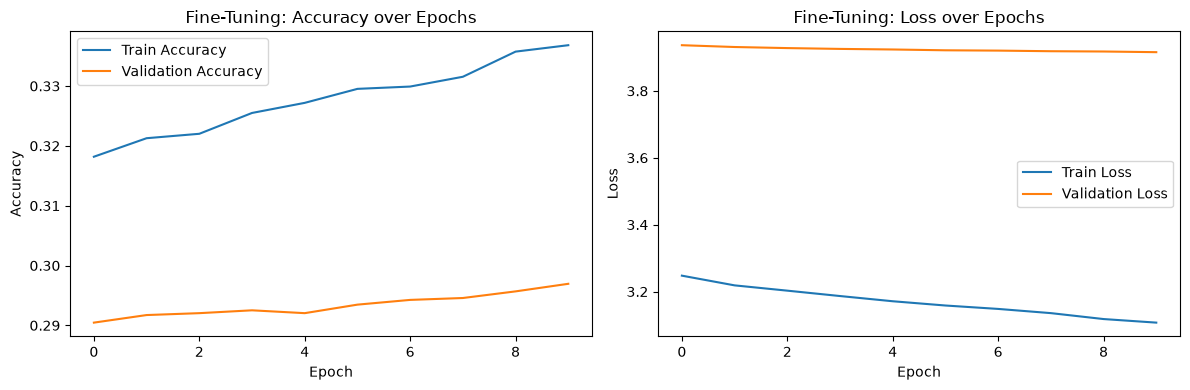

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_finetune.history["accuracy"], label="Train Accuracy")
plt.plot(history_finetune.history["val_accuracy"], label="Validation Accuracy")
plt.title("Fine-Tuning: Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_finetune.history["loss"], label="Train Loss")
plt.plot(history_finetune.history["val_loss"], label="Validation Loss")
plt.title("Fine-Tuning: Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Step 14: Easy side-by-side comparison

All three models were evaluated on the exact same held-out test set (`X_test`, `y_test`),
which none of them ever saw during training. That makes this comparison fair.


In [19]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["Accuracy", "Top-3 Accuracy", "Precision", "Recall", "Loss"]]
comparison_df


,Accuracy,Top-3 Accuracy,Precision,Recall,Loss
1. Baseline (no pretrained embeddings),0.2737,0.4108,0.2062,0.2737,4.2425
2. Transfer learning (frozen GloVe embeddings),0.2705,0.4110,0.2097,0.2705,4.2027
3. Fine-tuned (unfrozen GloVe embeddings),0.2838,0.4219,0.2243,0.2838,4.1611


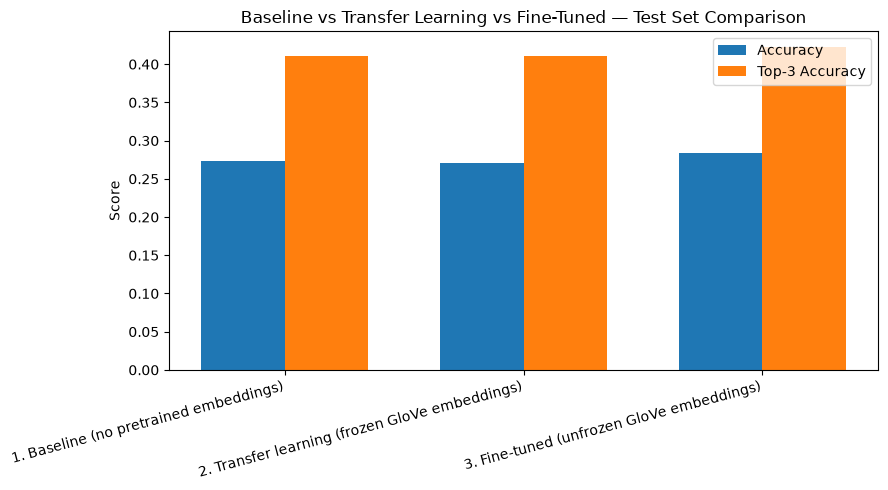

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width / 2, comparison_df["Accuracy"], width, label="Accuracy")
ax.bar(x + width / 2, comparison_df["Top-3 Accuracy"], width, label="Top-3 Accuracy")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Baseline vs Transfer Learning vs Fine-Tuned — Test Set Comparison")
ax.legend()

plt.tight_layout()
plt.show()


## Step 15: Qualitative comparison

Numbers are useful, but seeing actual predictions side by side makes the improvement easy to
understand at a glance.


In [21]:
def predict_next_words(model, tokenizer, seed_text, max_seq_len, num_words=3):
    text = seed_text
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding="pre")
        predicted_id = np.argmax(model.predict(token_list, verbose=0))

        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                predicted_word = word
                break

        text += " " + predicted_word
    return text

sample_seeds = [
    "place fried chicken",
    "mix the flour and",
    "preheat the oven to",
]

for seed in sample_seeds:
    baseline_result = predict_next_words(model_baseline, tokenizer, seed, MAX_SEQ_LEN, num_words=3)
    finetuned_result = predict_next_words(model_transfer, tokenizer, seed, MAX_SEQ_LEN, num_words=3)
    print(f"Seed:      {seed}")
    print(f"Baseline:  {baseline_result}")
    print(f"Fine-tuned: {finetuned_result}")
    print("-" * 60)


Seed:      place fried chicken
Baseline:  place fried chicken in a x
Fine-tuned: place fried chicken in a large
------------------------------------------------------------
Seed:      mix the flour and
Baseline:  mix the flour and salt in a
Fine-tuned: mix the flour and sugar in a
------------------------------------------------------------
Seed:      preheat the oven to
Baseline:  preheat the oven to u b grease
Fine-tuned: preheat the oven to u b grease
------------------------------------------------------------


## Step 16: Save the model and tokenizer for deployment

We save everything the FastAPI app needs to make predictions on its own, without re-running
any of the notebook: the fine-tuned model, the tokenizer, and the small config values
(`MAX_SEQ_LEN`, vocabulary size) it depends on.


In [22]:
os.makedirs("artifacts", exist_ok=True)

# Save the final (fine-tuned) model
model_transfer.save("artifacts/next_word_model.keras")

# Save the tokenizer
with open("artifacts/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save the small config values the API needs
config = {
    "MAX_SEQ_LEN": MAX_SEQ_LEN,
    "VOCAB_SIZE": VOCAB_SIZE,
    "EMBEDDING_DIM": EMBEDDING_DIM,
}
with open("artifacts/config.json", "w") as f:
    json.dump(config, f)

print("Saved model, tokenizer, and config to the 'artifacts' folder.")


Saved model, tokenizer, and config to the 'artifacts' folder.
